# Convergence Analysis for Colonel Blotto Simulations

This notebook analyzes the time to convergence for various match-ups in the Colonel Blotto game.

**Convergence Criteria:**
- **Retaining games**: Troop counts remain constant for 5 consecutive steps
- **Non-retaining games**: Average utility stabilizes (standard deviation < 1% of mean over a rolling window)

**Output metrics**: Mean and variance of convergence time across all simulations for each match-up

In [2]:
%pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from typing import Tuple, Dict, List
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.9 MB 20.7 MB/s eta 0:00:01
   ----------------------------- ---------- 7.3/9.9 MB 25.4 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 22.9 MB/s  0:00:00
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

   ---------------------------------------- 0/3 [tzdata]
   ---------------------------------------- 0/3 [tzdata]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ------------- -------------------------- 1/3 [pandas]
   ----------

In [3]:
# Configuration
RESULTS_DIR = Path('results')
RETAINING_CONSECUTIVE_STEPS = 5  # Number of consecutive steps for retaining convergence
NON_RETAINING_WINDOW = 10  # Rolling window size for non-retaining convergence
NON_RETAINING_THRESHOLD = 0.01  # 1% threshold for utility stabilization

print(f"Results directory: {RESULTS_DIR}")
print(f"Retaining convergence criterion: {RETAINING_CONSECUTIVE_STEPS} consecutive constant steps")
print(f"Non-retaining convergence criterion: stdev < {NON_RETAINING_THRESHOLD*100}% of mean over {NON_RETAINING_WINDOW} step window")

Results directory: results
Retaining convergence criterion: 5 consecutive constant steps
Non-retaining convergence criterion: stdev < 1.0% of mean over 10 step window


## Helper Functions

In [4]:
def calculate_troop_counts(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate running troop counts for each player in a retaining game.
    """
    # Get initial troop counts from first row
    # Assuming natt and ndef are the same across the simulation
    initial_troops = 10  # This could be extracted from filename if needed
    
    # Sort by sim_id and stage
    df = df.sort_values(['sim_id', 'stage']).copy()
    
    # Calculate cumulative troop changes
    df['attacker_troops'] = initial_troops
    df['defender_troops'] = initial_troops
    
    for sim_id in df['sim_id'].unique():
        mask = df['sim_id'] == sim_id
        sim_data = df[mask].copy()
        
        attacker_troops = [initial_troops]
        defender_troops = [initial_troops]
        
        for i, row in enumerate(sim_data.itertuples()):
            if i > 0:
                # Attacker loses captured troops, gains defender's captured troops
                new_att = attacker_troops[-1] - row.attacker_troops_captured + row.defender_troops_captured
                # Defender loses captured troops, gains attacker's captured troops  
                new_def = defender_troops[-1] - row.defender_troops_captured + row.attacker_troops_captured
                attacker_troops.append(new_att)
                defender_troops.append(new_def)
        
        df.loc[mask, 'attacker_troops'] = attacker_troops
        df.loc[mask, 'defender_troops'] = defender_troops
    
    return df

In [5]:
def find_retaining_convergence(sim_df: pd.DataFrame) -> int:
    """
    Find the step at which troop counts converge (remain constant for N consecutive steps).
    Returns the step number, or -1 if convergence not reached.
    """
    sim_df = sim_df.sort_values('stage')
    
    attacker_troops = sim_df['attacker_troops'].values
    defender_troops = sim_df['defender_troops'].values
    stages = sim_df['stage'].values
    
    if len(attacker_troops) < RETAINING_CONSECUTIVE_STEPS:
        return -1
    
    # Check for consecutive constant values
    for i in range(len(attacker_troops) - RETAINING_CONSECUTIVE_STEPS + 1):
        att_window = attacker_troops[i:i+RETAINING_CONSECUTIVE_STEPS]
        def_window = defender_troops[i:i+RETAINING_CONSECUTIVE_STEPS]
        
        # Check if all values in window are the same
        if (np.all(att_window == att_window[0]) and 
            np.all(def_window == def_window[0])):
            return stages[i + RETAINING_CONSECUTIVE_STEPS - 1]  # Return the last step of convergence window
    
    return -1  # Not converged

In [6]:
def find_non_retaining_convergence(sim_df: pd.DataFrame) -> int:
    """
    Find the step at which utility converges (stabilizes within threshold).
    Returns the step number, or -1 if convergence not reached.
    """
    sim_df = sim_df.sort_values('stage')
    
    utility = sim_df['utility_current'].values
    stages = sim_df['stage'].values
    
    if len(utility) < NON_RETAINING_WINDOW:
        return -1
    
    # Check rolling window for stability
    for i in range(len(utility) - NON_RETAINING_WINDOW + 1):
        window = utility[i:i+NON_RETAINING_WINDOW]
        mean_util = np.mean(window)
        std_util = np.std(window)
        
        # Check if standard deviation is less than threshold % of mean
        # Handle case where mean is 0 or very small
        if mean_util == 0:
            # If mean is 0, consider converged if std is also near 0
            if std_util < 0.01:
                return stages[i + NON_RETAINING_WINDOW - 1]
        else:
            relative_std = std_util / abs(mean_util)
            if relative_std < NON_RETAINING_THRESHOLD:
                return stages[i + NON_RETAINING_WINDOW - 1]
    
    return -1  # Not converged

## Load and Process All Result Files

In [13]:
# Get all CSV files and filter for dp_exploit and dp_nash only (non-retaining games)
all_csv_files = sorted(RESULTS_DIR.glob('*.csv'))
print(f"Found {len(all_csv_files)} total result files")

# Filter for only dp_exploit and dp_nash games that are non-retaining
csv_files = [f for f in all_csv_files if 
             ('dp_exploit' in f.name or 'dp_nash' in f.name) and 
             'retain-False' in f.name]
print(f"Filtered to {len(csv_files)} non-retaining files with dp_exploit or dp_nash controllers")

# Show all filenames (should be a small set now)
print("\nFiles to analyze:")
for f in csv_files:
    print(f"  {f.name}")

Found 1296 total result files
Filtered to 360 non-retaining files with dp_exploit or dp_nash controllers

Files to analyze:
  att-dp_exploit__def-dp_exploit__sims-1000__steps-100__natt-10__ndef-10__m-0.25__p-1.0__alpha-0.5__c0-0.25__retain-False.csv
  att-dp_exploit__def-dp_exploit__sims-1000__steps-100__natt-10__ndef-10__m-0.5__p-1.0__alpha-0.1__c0-0.25__retain-False.csv
  att-dp_exploit__def-dp_exploit__sims-1000__steps-100__natt-10__ndef-10__m-0.5__p-1.0__alpha-0.3__c0-0.25__retain-False.csv
  att-dp_exploit__def-dp_exploit__sims-1000__steps-100__natt-10__ndef-10__m-0.5__p-1.0__alpha-0.5__c0-0.0__retain-False.csv
  att-dp_exploit__def-dp_exploit__sims-1000__steps-100__natt-10__ndef-10__m-0.5__p-1.0__alpha-0.5__c0-0.25__retain-False.csv
  att-dp_exploit__def-dp_exploit__sims-1000__steps-100__natt-10__ndef-10__m-0.5__p-1.0__alpha-0.5__c0-0.5__retain-False.csv
  att-dp_exploit__def-dp_exploit__sims-1000__steps-100__natt-10__ndef-10__m-0.5__p-1.0__alpha-0.7__c0-0.25__retain-False.csv
  

In [11]:
def analyze_convergence_for_file(filepath: Path) -> Dict:
    """
    Analyze convergence for all simulations in a single CSV file.
    Returns dictionary with convergence statistics.
    """
    df = pd.read_csv(filepath)
    
    # Extract metadata from first row
    meta = df.iloc[0]
    retain = meta['retain']
    attacker = meta['attacker_controller']
    defender = meta['defender_controller']
    alpha = meta['alpha']
    m = meta['m']
    c0 = meta['c0']
    
    convergence_times = []
    
    if retain:
        # Calculate troop counts for retaining game
        df = calculate_troop_counts(df)
    
    # Analyze each simulation
    for sim_id in df['sim_id'].unique():
        sim_df = df[df['sim_id'] == sim_id]
        
        if retain:
            conv_time = find_retaining_convergence(sim_df)
        else:
            conv_time = find_non_retaining_convergence(sim_df)
        
        if conv_time > 0:
            convergence_times.append(conv_time)
    
    # Calculate statistics
    result = {
        'filename': filepath.name,
        'attacker': attacker,
        'defender': defender,
        'retain': retain,
        'alpha': alpha,
        'm': m,
        'c0': c0,
        'total_sims': len(df['sim_id'].unique()),
        'converged_sims': len(convergence_times),
        'convergence_rate': len(convergence_times) / len(df['sim_id'].unique()) if len(df['sim_id'].unique()) > 0 else 0,
        'mean_convergence_time': np.mean(convergence_times) if convergence_times else np.nan,
        'variance_convergence_time': np.var(convergence_times) if convergence_times else np.nan,
        'std_convergence_time': np.std(convergence_times) if convergence_times else np.nan,
        'median_convergence_time': np.median(convergence_times) if convergence_times else np.nan,
        'min_convergence_time': np.min(convergence_times) if convergence_times else np.nan,
        'max_convergence_time': np.max(convergence_times) if convergence_times else np.nan,
    }
    
    return result

In [14]:
# Analyze all files
print("Analyzing convergence for all files...")
results = []

for i, filepath in enumerate(csv_files):
    if (i + 1) % 10 == 0:
        print(f"  Processed {i + 1}/{len(csv_files)} files...")
    
    try:
        result = analyze_convergence_for_file(filepath)
        results.append(result)
    except Exception as e:
        print(f"  Error processing {filepath.name}: {e}")

print(f"\nCompleted analysis of {len(results)} files")

# Create results dataframe
results_df = pd.DataFrame(results)
results_df.head(10)

Analyzing convergence for all files...
  Processed 10/360 files...
  Processed 20/360 files...
  Processed 30/360 files...
  Processed 40/360 files...
  Processed 50/360 files...
  Processed 60/360 files...
  Processed 70/360 files...
  Processed 80/360 files...
  Processed 90/360 files...
  Processed 100/360 files...
  Processed 110/360 files...
  Processed 120/360 files...
  Processed 130/360 files...
  Processed 140/360 files...
  Processed 150/360 files...
  Processed 160/360 files...
  Processed 170/360 files...
  Processed 180/360 files...
  Processed 190/360 files...
  Processed 200/360 files...
  Processed 210/360 files...
  Processed 220/360 files...
  Processed 230/360 files...
  Processed 240/360 files...
  Processed 250/360 files...
  Processed 260/360 files...
  Processed 270/360 files...
  Processed 280/360 files...
  Processed 290/360 files...
  Processed 300/360 files...
  Processed 310/360 files...
  Processed 320/360 files...
  Processed 330/360 files...
  Processed 3

,filename,attacker,defender,retain,alpha,m,c0,total_sims,converged_sims,convergence_rate,mean_convergence_time,variance_convergence_time,std_convergence_time,median_convergence_time,min_convergence_time,max_convergence_time
0,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,False,0.5,0.25,0.25,1000,816,0.816,41.811275,664.503598,25.777967,35.0,10.0,99.0
1,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,False,0.1,0.50,0.25,1000,465,0.465,48.193548,704.409851,26.540721,46.0,10.0,100.0
2,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,False,0.3,0.50,0.25,1000,606,0.606,45.019802,655.864294,25.609848,43.0,10.0,100.0
3,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,False,0.5,0.50,0.00,1000,803,0.803,38.859278,600.942837,24.514135,35.0,10.0,100.0
4,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,False,0.5,0.50,0.25,1000,801,0.801,39.710362,596.705124,24.427548,36.0,10.0,100.0
5,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,False,0.5,0.50,0.50,1000,798,0.798,39.837093,597.885742,24.451702,35.5,10.0,100.0
6,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,False,0.7,0.50,0.25,1000,526,0.526,49.250951,693.857176,26.341169,47.0,10.0,100.0
7,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,False,0.9,0.50,0.25,1000,779,0.779,41.092426,756.486964,27.504308,36.0,10.0,100.0
8,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,False,0.5,0.75,0.25,1000,834,0.834,38.559952,573.711634,23.952278,34.0,10.0,100.0
9,att-dp_exploit__def-dp_exploit__sims-1000__ste...,dp_exploit,dp_exploit,False,0.5,1.00,0.25,1000,1000,1.000,17.543000,99.232151,9.961534,14.0,10.0,64.0


## Summary Statistics

In [15]:
# Overall summary
print("="*80)
print("OVERALL CONVERGENCE SUMMARY")
print("="*80)
print(f"\nTotal configurations analyzed: {len(results_df)}")
print(f"Retaining games: {results_df['retain'].sum()}")
print(f"Non-retaining games: {(~results_df['retain']).sum()}")
print(f"\nAverage convergence rate: {results_df['convergence_rate'].mean():.2%}")
print(f"  Retaining: {results_df[results_df['retain']]['convergence_rate'].mean():.2%}")
print(f"  Non-retaining: {results_df[~results_df['retain']]['convergence_rate'].mean():.2%}")

OVERALL CONVERGENCE SUMMARY

Total configurations analyzed: 360
Retaining games: 0
Non-retaining games: 360

Average convergence rate: 75.80%
  Retaining: nan%
  Non-retaining: 75.80%


In [16]:
# Summary by game type
print("\n" + "="*80)
print("CONVERGENCE TIME STATISTICS BY GAME TYPE")
print("="*80)

for retain in [True, False]:
    subset = results_df[results_df['retain'] == retain]
    game_type = "RETAINING" if retain else "NON-RETAINING"
    
    print(f"\n{game_type} GAMES:")
    print(f"  Mean convergence time: {subset['mean_convergence_time'].mean():.2f} ± {subset['mean_convergence_time'].std():.2f} steps")
    print(f"  Mean variance: {subset['variance_convergence_time'].mean():.2f}")
    print(f"  Range: [{subset['mean_convergence_time'].min():.2f}, {subset['mean_convergence_time'].max():.2f}] steps")


CONVERGENCE TIME STATISTICS BY GAME TYPE

RETAINING GAMES:
  Mean convergence time: nan ± nan steps
  Mean variance: nan
  Range: [nan, nan] steps

NON-RETAINING GAMES:
  Mean convergence time: 34.52 ± 14.01 steps
  Mean variance: 448.07
  Range: [10.00, 61.32] steps


In [17]:
# Summary by controller matchup
print("\n" + "="*80)
print("CONVERGENCE TIME BY CONTROLLER MATCHUP")
print("="*80)

matchup_summary = results_df.groupby(['attacker', 'defender', 'retain']).agg({
    'mean_convergence_time': ['mean', 'std', 'count'],
    'variance_convergence_time': 'mean',
    'convergence_rate': 'mean'
}).round(2)

matchup_summary.columns = ['_'.join(col).strip() for col in matchup_summary.columns.values]
matchup_summary = matchup_summary.reset_index()
matchup_summary = matchup_summary.sort_values('mean_convergence_time_mean')

print(matchup_summary.to_string())


CONVERGENCE TIME BY CONTROLLER MATCHUP
      attacker    defender  retain  mean_convergence_time_mean  mean_convergence_time_std  mean_convergence_time_count  variance_convergence_time_mean  convergence_rate_mean
12        even  dp_exploit   False                       11.34                       4.01                           17                           21.84                   0.94
3   dp_exploit          mc   False                       27.57                      13.34                           18                          308.24                   0.87
5   dp_exploit      random   False                       28.17                      13.89                           18                          315.42                   0.85
4   dp_exploit        mcts   False                       28.69                      11.52                           18                          342.10                   0.90
13        even     dp_nash   False                       31.36                      13.59 

## Visualizations

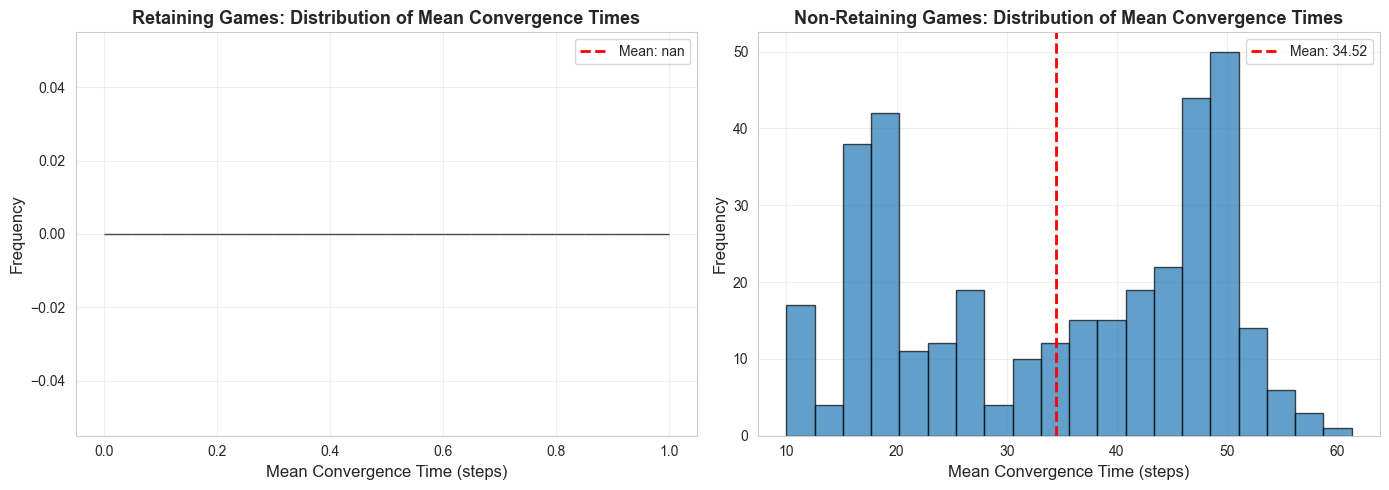

In [18]:
# Plot 1: Distribution of mean convergence times
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, retain in enumerate([True, False]):
    subset = results_df[results_df['retain'] == retain]
    game_type = "Retaining" if retain else "Non-Retaining"
    
    axes[idx].hist(subset['mean_convergence_time'].dropna(), bins=20, alpha=0.7, edgecolor='black')
    axes[idx].axvline(subset['mean_convergence_time'].mean(), color='red', linestyle='--', 
                     linewidth=2, label=f'Mean: {subset["mean_convergence_time"].mean():.2f}')
    axes[idx].set_xlabel('Mean Convergence Time (steps)', fontsize=12)
    axes[idx].set_ylabel('Frequency', fontsize=12)
    axes[idx].set_title(f'{game_type} Games: Distribution of Mean Convergence Times', fontsize=13, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/convergence_time_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

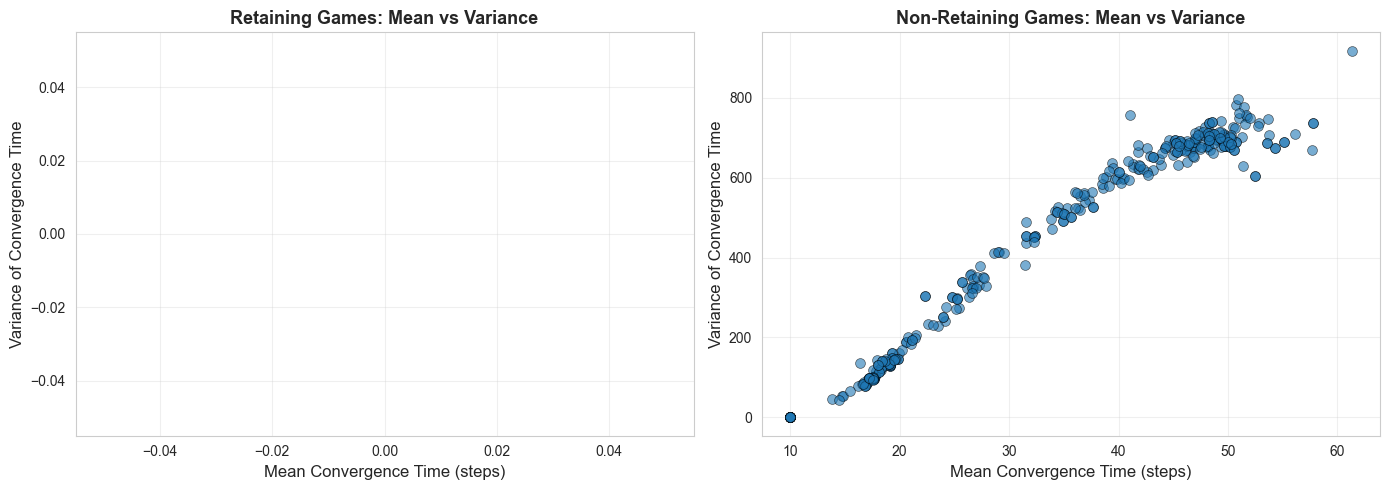

In [19]:
# Plot 2: Mean vs Variance scatter plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, retain in enumerate([True, False]):
    subset = results_df[results_df['retain'] == retain].dropna(subset=['mean_convergence_time', 'variance_convergence_time'])
    game_type = "Retaining" if retain else "Non-Retaining"
    
    axes[idx].scatter(subset['mean_convergence_time'], subset['variance_convergence_time'], 
                     alpha=0.6, s=50, edgecolors='black', linewidth=0.5)
    axes[idx].set_xlabel('Mean Convergence Time (steps)', fontsize=12)
    axes[idx].set_ylabel('Variance of Convergence Time', fontsize=12)
    axes[idx].set_title(f'{game_type} Games: Mean vs Variance', fontsize=13, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/convergence_mean_vs_variance.png', dpi=300, bbox_inches='tight')
plt.show()

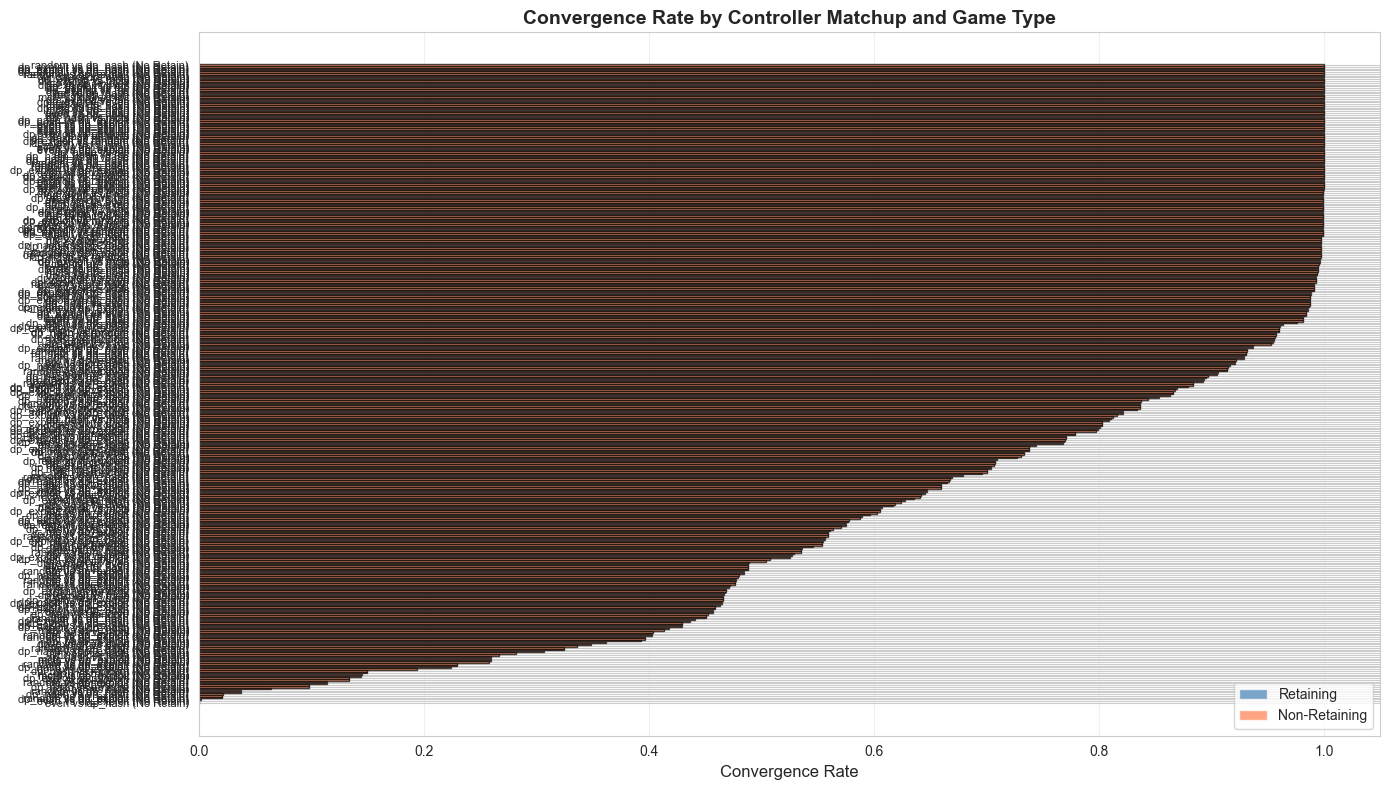

In [20]:
# Plot 3: Convergence rate by matchup
fig, ax = plt.subplots(figsize=(14, 8))

# Create matchup labels
results_df['matchup'] = results_df['attacker'] + ' vs ' + results_df['defender']
results_df['game_type'] = results_df['retain'].map({True: 'Retain', False: 'No Retain'})
results_df['full_label'] = results_df['matchup'] + ' (' + results_df['game_type'] + ')'

# Sort by convergence rate
plot_data = results_df.sort_values('convergence_rate', ascending=True)

# Create bar plot
colors = plot_data['retain'].map({True: 'steelblue', False: 'coral'})
bars = ax.barh(range(len(plot_data)), plot_data['convergence_rate'], color=colors, alpha=0.7, edgecolor='black')

ax.set_yticks(range(len(plot_data)))
ax.set_yticklabels(plot_data['full_label'], fontsize=8)
ax.set_xlabel('Convergence Rate', fontsize=12)
ax.set_title('Convergence Rate by Controller Matchup and Game Type', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', alpha=0.7, label='Retaining'),
                   Patch(facecolor='coral', alpha=0.7, label='Non-Retaining')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('plots/convergence_rate_by_matchup.png', dpi=300, bbox_inches='tight')
plt.show()

ValueError: Dimensions of labels and X must be compatible

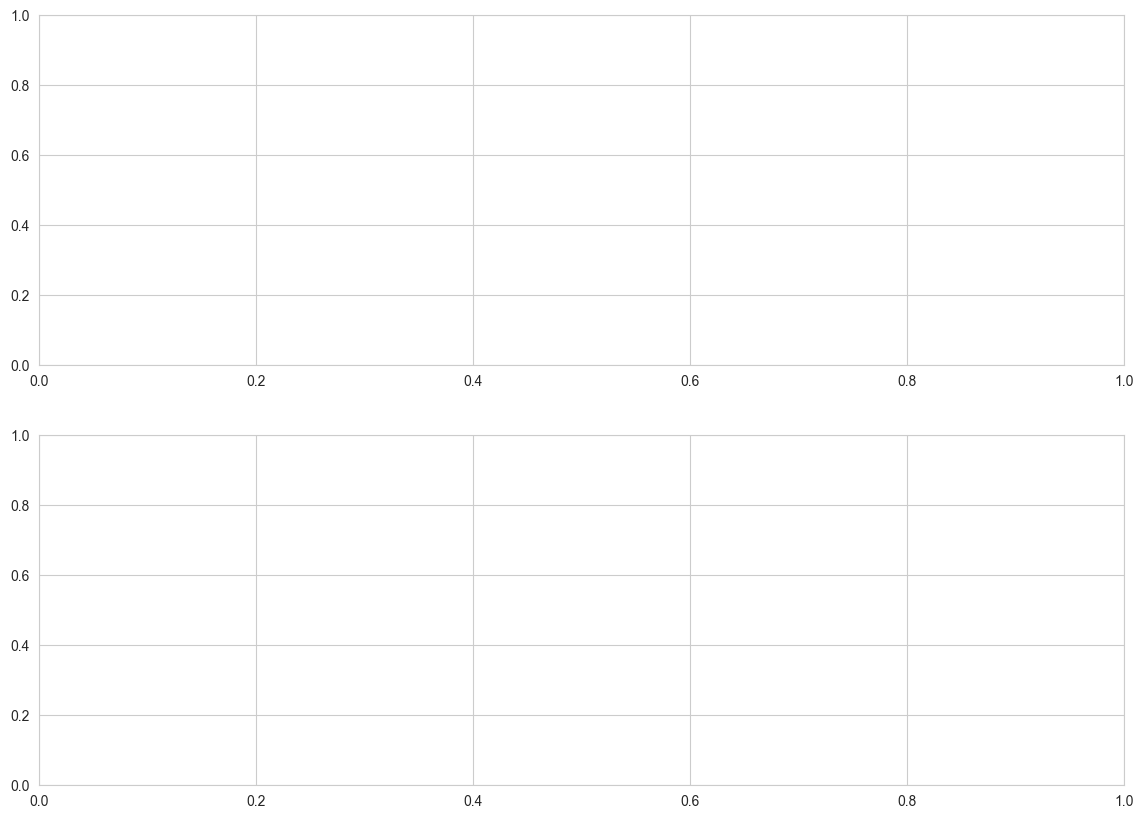

In [21]:
# Plot 4: Box plot of convergence times by controller matchup
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

for idx, retain in enumerate([True, False]):
    subset = results_df[results_df['retain'] == retain]
    game_type = "Retaining" if retain else "Non-Retaining"
    
    # Prepare data for box plot
    matchups = subset['matchup'].unique()
    data_to_plot = [subset[subset['matchup'] == m]['mean_convergence_time'].dropna().values for m in matchups]
    
    bp = axes[idx].boxplot(data_to_plot, labels=matchups, patch_artist=True)
    
    # Color the boxes
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue' if retain else 'lightcoral')
        patch.set_alpha(0.7)
    
    axes[idx].set_ylabel('Mean Convergence Time (steps)', fontsize=12)
    axes[idx].set_title(f'{game_type} Games: Convergence Time Distribution by Matchup', 
                       fontsize=13, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('plots/convergence_time_boxplot.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# Plot 5: Effect of parameter variations
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

params = ['alpha', 'm', 'c0']
param_labels = ['Alpha (α)', 'Obedience Utility (m)', 'Initial Capture Rate (c₀)']

for idx, (param, label) in enumerate(zip(params, param_labels)):
    for retain in [True, False]:
        subset = results_df[results_df['retain'] == retain].dropna(subset=['mean_convergence_time'])
        game_type = "Retaining" if retain else "Non-Retaining"
        marker = 'o' if retain else 's'
        
        # Group by parameter and calculate mean
        param_grouped = subset.groupby(param)['mean_convergence_time'].mean()
        
        axes[idx].plot(param_grouped.index, param_grouped.values, marker=marker, 
                      label=game_type, linewidth=2, markersize=8, alpha=0.7)
    
    axes[idx].set_xlabel(label, fontsize=12)
    axes[idx].set_ylabel('Mean Convergence Time (steps)', fontsize=12)
    axes[idx].set_title(f'Effect of {label} on Convergence Time', fontsize=12, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/parameter_effects.png', dpi=300, bbox_inches='tight')
plt.show()

## Export Results

In [ ]:
# Save detailed results to CSV
output_file = 'convergence_analysis_results.csv'
results_df.to_csv(output_file, index=False)
print(f"Results saved to: {output_file}")

# Save summary statistics
summary_file = 'convergence_analysis_summary.csv'
matchup_summary.to_csv(summary_file, index=False)
print(f"Summary statistics saved to: {summary_file}")

## Key Findings

Run all cells above to populate this with specific findings from your data.